In [1]:
!pip install torch torchvision

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from src.utils import load_cifar10_longtail
import numpy as np
from tqdm import tqdm # Thư viện hiện thanh tiến trình

# 1. Thiết lập thiết bị
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Đang sử dụng thiết bị: {device}")

# 2. Tải Model DINOv2
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device)
model.eval()

# 3. Transform chuẩn
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Lớp hỗ trợ để đưa dữ liệu vào DataLoader ---
class CifarLongtailDataset(Dataset):
    def __init__(self, images, transform=None):
        self.images = images
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img

# 4. Hàm trích xuất đặc trưng tối ưu (Xử lý theo Batch)
def extract_features_fast(X_images, batch_size=32):
    dataset = CifarLongtailDataset(X_images, transform=transform)
    # DataLoader giúp gộp các ảnh thành Batch để xử lý song song
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    feats = []
    # tqdm sẽ tạo ra thanh tiến trình 
    with torch.no_grad():
        for batch in tqdm(loader, desc="Đang trích xuất đặc trưng"):
            batch = batch.to(device)
            feat = model(batch)
            feats.append(feat.cpu().numpy())
            
    return np.vstack(feats)

# --- THỰC THI ---

X_longtail, Y_longtail = load_cifar10_longtail('../data/cifar-10-batches-py', imbalance_ratio=0.1)

# Trích xuất với Batch size 64 (Nếu máy có GPU mạnh bạn có thể tăng lên 128)
X_features = extract_features_fast(X_longtail, batch_size=64)

print(f"Xong! Kích thước mảng đặc trưng: {X_features.shape}")

# --- QUAN TRỌNG: Lưu lại để không phải chạy lại lần nữa ---
# Bạn hãy tạo folder 'processed_data' nếu chưa có
os.makedirs('../data/processed', exist_ok=True)
np.save('../data/processed/X_features_cifar_0.1.npy', X_features)
np.save('../data/processed/Y_longtail_cifar_0.1.npy', Y_longtail)
print("Đã lưu đặc trưng vào thư mục data/processed/")

Đang sử dụng thiết bị: cpu


Using cache found in C:\Users\ACER/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\ACER/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\ACER/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\ACER/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Lớp 0: giữ lại 5000 ảnh
Lớp 1: giữ lại 3871 ảnh
Lớp 2: giữ lại 2997 ảnh
Lớp 3: giữ lại 2320 ảnh
Lớp 4: giữ lại 1796 ảnh
Lớp 5: giữ lại 1391 ảnh
Lớp 6: giữ lại 1077 ảnh
Lớp 7: giữ lại 834 ảnh
Lớp 8: giữ lại 645 ảnh
Lớp 9: giữ lại 500 ảnh


Đang trích xuất đặc trưng:  32%|███▏      | 103/320 [04:58<10:28,  2.89s/it]


KeyboardInterrupt: 

In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import sys
import os
from sklearn.cluster import KMeans

# 1. Thêm đường dẫn src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.model_copy import hierarchical_kmeans_resampling

# 2. Load dữ liệu đặc trưng đã lưu (Đảm bảo đúng đường dẫn trong ảnh của bạn)
X_features = np.load('../data/processed/X_features_cifar_0.1.npy').astype(np.float32)
Y_longtail = np.load('../data/processed/Y_longtail_cifar_0.1.npy')

print(f"Đã load xong X_features: {X_features.shape}")
print(f"Đã load xong Y_longtail: {Y_longtail.shape}")

Đã load xong X_features: (20431, 384)
Đã load xong Y_longtail: (20431,)


In [31]:
%load_ext autoreload
%autoreload 2
from sklearn.preprocessing import normalize
# --- CẤU HÌNH TỐI ƯU ---
X_feat_norm = normalize(X_features, axis=1)

# --- CẤU HÌNH TỐI ƯU THỜI GIAN (10 PHÚT LEVEL 1) ---
T_steps = 3
# Level 1 để 1200 là đủ "mịn" cho 20k ảnh, 2000 là hơi dư thừa
k_list_fine = [1200, 800, 500] 

m_iterations = 10 # Giữ nguyên m=10 để centroids di chuyển tốt

centroids_cifar = hierarchical_kmeans_resampling(
    X_feat_norm, 
    k_list_fine, 
    T=T_steps, 
    m=m_iterations, 
    num_init=5,  # QUAN TRỌNG NHẤT: Để là 1 thay vì 5.
    random_state=42
)

# --- GÁN NHÃN ---
n_final_clusters = k_list_fine[-1] # 500
km_fine = KMeans(n_clusters=n_final_clusters, init=centroids_cifar, n_init=1).fit(X_feat_norm)
labels_fine = km_fine.labels_

# --- CHIẾN THUẬT LẤY MẪU ĐỂ LÀM PHẲNG ---
# Tính số lượng mẫu trung bình mỗi cụm đang có: 20431 / 500 = ~40
# Theo ý bạn, chúng ta lấy một nửa con số trung bình này làm mốc cố định cho mỗi cụm
avg_samples_per_cluster = len(X_feat_norm) // n_final_clusters
target_per_cluster = max(1, avg_samples_per_cluster // 2) 

print(f"Mỗi cụm sẽ cố gắng lấy tối đa: {target_per_cluster} ảnh")

curated_idx = []
for i in range(n_final_clusters):
    idx_cluster = np.where(labels_fine == i)[0]
    if len(idx_cluster) == 0: continue
    
    # Tính khoảng cách
    d = np.linalg.norm(X_feat_norm[idx_cluster] - centroids_cifar[i], axis=1)
    
    # Lấy mẫu: 
    # Nếu cụm đông, nó cũng chỉ được lấy đúng target_per_cluster (giúp nén lớp đa số)
    # Nếu cụm vắng, nó lấy hết hoặc lấy tối đa có thể (giúp giữ lớp thiểu số)
    n_to_take = min(len(idx_cluster), target_per_cluster)
    
    top_idx = idx_cluster[np.argsort(d)[:n_to_take]]
    curated_idx.extend(top_idx)

Y_curated_new = Y_longtail[curated_idx]
print(f"Tổng số ảnh sau làm phẳng: {len(curated_idx)}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
new hkm
--- Level 1/3 (k=1200, r_t tự động=8) ---
--- Level 2/3 (k=800, r_t tự động=1) ---
--- Level 3/3 (k=500, r_t tự động=1) ---
Mỗi cụm sẽ cố gắng lấy tối đa: 20 ảnh
Tổng số ảnh sau làm phẳng: 6164


In [34]:
%load_ext autoreload
%autoreload 2
from sklearn.preprocessing import normalize
# --- CẤU HÌNH TỐI ƯU ---
X_feat_norm = normalize(X_features, axis=1)

# --- CẤU HÌNH TỐI ƯU THỜI GIAN (10 PHÚT LEVEL 1) ---
T_steps = 3
# Level 1 để 1200 là đủ "mịn" cho 20k ảnh, 2000 là hơi dư thừa
k_list_fine = [1200, 800, 500] 

m_iterations = 10 # Giữ nguyên m=10 để centroids di chuyển tốt

centroids_cifar = hierarchical_kmeans_resampling(
    X_feat_norm, 
    k_list_fine, 
    T=T_steps, 
    m=m_iterations, 
    num_init=5,  # QUAN TRỌNG NHẤT: Để là 1 thay vì 5.
    random_state=42
)

# --- GÁN NHÃN ---
n_final_clusters = k_list_fine[-1] # Lúc này là 800
km_fine = KMeans(n_clusters=n_final_clusters, init=centroids_cifar, n_init=1).fit(X_feat_norm)
labels_fine = km_fine.labels_

# --- CHIẾN THUẬT "NÉN" MẠNH ---
# Thay vì lấy 20 (avg//2), ta chỉ lấy khoảng 5-8 ảnh mỗi cụm.
# Lý do: Lớp 0, 2 chiếm rất nhiều cụm, nếu mỗi cụm chỉ cho lấy 5 ảnh, 
# tổng số lượng của chúng sẽ bị kéo sập xuống ngay lập tức.
target_per_cluster = 5 

print(f"Mỗi cụm chỉ được lấy tối đa: {target_per_cluster} ảnh để ép các lớp đa số")

curated_idx = []
for i in range(n_final_clusters):
    idx_cluster = np.where(labels_fine == i)[0]
    if len(idx_cluster) == 0: continue
    
    d = np.linalg.norm(X_feat_norm[idx_cluster] - centroids_cifar[i], axis=1)
    
    # Lấy ít ảnh hơn trên mỗi cụm giúp san bằng tỉ lệ giữa các cụm đông và cụm vắng
    n_to_take = min(len(idx_cluster), target_per_cluster)
    
    top_idx = idx_cluster[np.argsort(d)[:n_to_take]]
    curated_idx.extend(top_idx)

Y_curated_new = Y_longtail[curated_idx]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
new hkm
--- Level 1/3 (k=1200, r_t tự động=8) ---
--- Level 2/3 (k=800, r_t tự động=1) ---
--- Level 3/3 (k=500, r_t tự động=1) ---
Mỗi cụm chỉ được lấy tối đa: 5 ảnh để ép các lớp đa số


In [35]:
# --- 1. Lấy mẫu ngẫu nhiên (Random Sampling - Baseline) ---
# Chọn đại 1000 ảnh từ toàn bộ dữ liệu gốc
random_indices = np.random.choice(len(X_features), 6000, replace=False)
Y_random_subset = Y_longtail[random_indices]

# --- 2. Lấy mẫu theo HK-means (Our Balanced Sampling) ---
# Ở bước này, hãy dùng đúng tên biến bạn đã tạo ở ô trên
curated_indices = []

# Thay vì range(100), bạn nên dùng range(n_final_clusters) hoặc range(500)
# vì ở bước trên bạn đã chia làm 500 cụm
for i in range(n_final_clusters): 
    # ĐỔI TÊN: cluster_labels -> labels_fine
    idx_in_cluster = np.where(labels_fine == i)[0]
    if len(idx_in_cluster) == 0: continue
    
    # ĐỔI TÊN: centroids_final -> centroids_cifar
    # ĐỔI TÊN: X_features -> X_feat_norm (vì bạn đã normalize ở bước trên)
    dists = np.linalg.norm(X_feat_norm[idx_in_cluster] - centroids_cifar[i], axis=1)
    
    # Lấy 2 ảnh gần nhất (để khớp với tổng ~1000 ảnh)
    top_k_idx = idx_in_cluster[np.argsort(dists)[:2]]
    curated_indices.extend(top_k_idx)

Y_curated_subset = Y_longtail[curated_indices]

### ưu tiên nhỏ

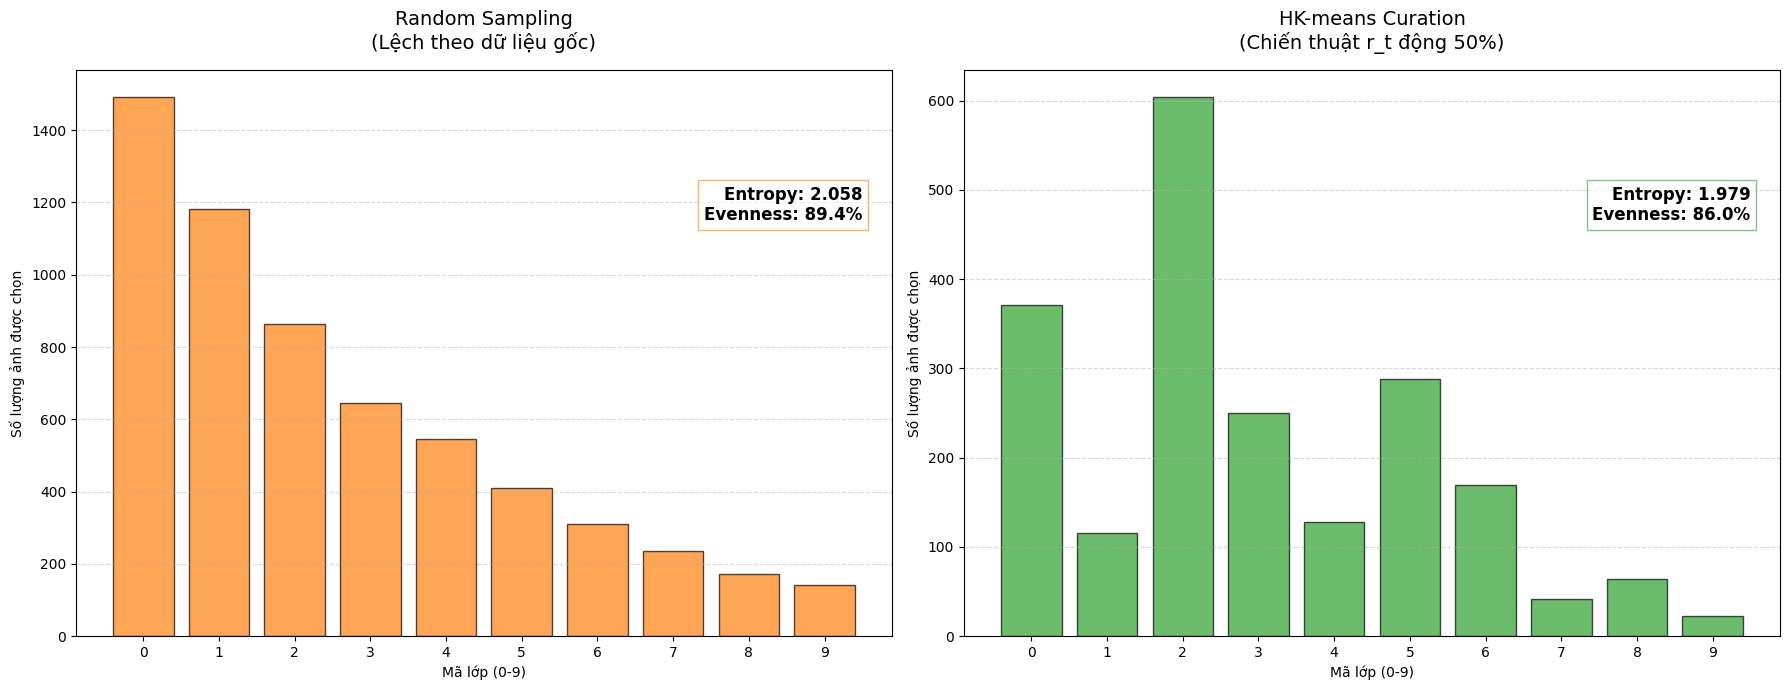

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def plot_distribution(y_data, title, color):
    # 1. Thống kê số lượng
    classes, counts = np.unique(y_data, return_counts=True)
    full_counts = np.zeros(10)
    for cls, count in zip(classes, counts):
        full_counts[int(cls)] = count
        
    # 2. TÍNH ENTROPY VÀ ĐỘ PHẲNG
    probs = full_counts / np.sum(full_counts)
    ent = entropy(probs)
    max_ent = np.log(10) # ln(10) xấp xỉ 2.302
    evenness = ent / max_ent
    
    # 3. VẼ BIỂU ĐỒ
    plt.bar(range(10), full_counts, color=color, alpha=0.7, edgecolor='black')
    
    # 4. CHÈN CHỈ SỐ LÊN HÌNH (Text box)
    info_text = f"Entropy: {ent:.3f}\nEvenness: {evenness:.1%}"
    # Đặt text ở vị trí phía trên bên phải của mỗi biểu đồ
    plt.text(9.5, max(full_counts) * 0.8, info_text, 
             fontsize=12, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor=color),
             ha='right', va='center')

    plt.xlabel('Mã lớp (0-9)')
    plt.ylabel('Số lượng ảnh được chọn')
    plt.title(title, fontsize=14, pad=15)
    plt.xticks(range(10))
    plt.grid(axis='y', linestyle='--', alpha=0.5)

# --- THỰC HIỆN VẼ ---
plt.figure(figsize=(18, 7))

# Biểu đồ bên trái: Random
plt.subplot(1, 2, 1)
# Giả sử Y_random_subset đã được tạo từ bước trước của bạn
plot_distribution(Y_random_subset, "Random Sampling\n(Lệch theo dữ liệu gốc)", "tab:orange")

# Biểu đồ bên phải: HK-means (Chiến thuật r_t động 50%)
plt.subplot(1, 2, 2)
# Dùng Y_curated_new bạn vừa tạo ra từ HK-means
plot_distribution(Y_curated_new, "HK-means Curation\n(Chiến thuật r_t động 50%)", "tab:green")

plt.tight_layout()
plt.show()

đổi quy tắt lấy đợt cuối (r/2)

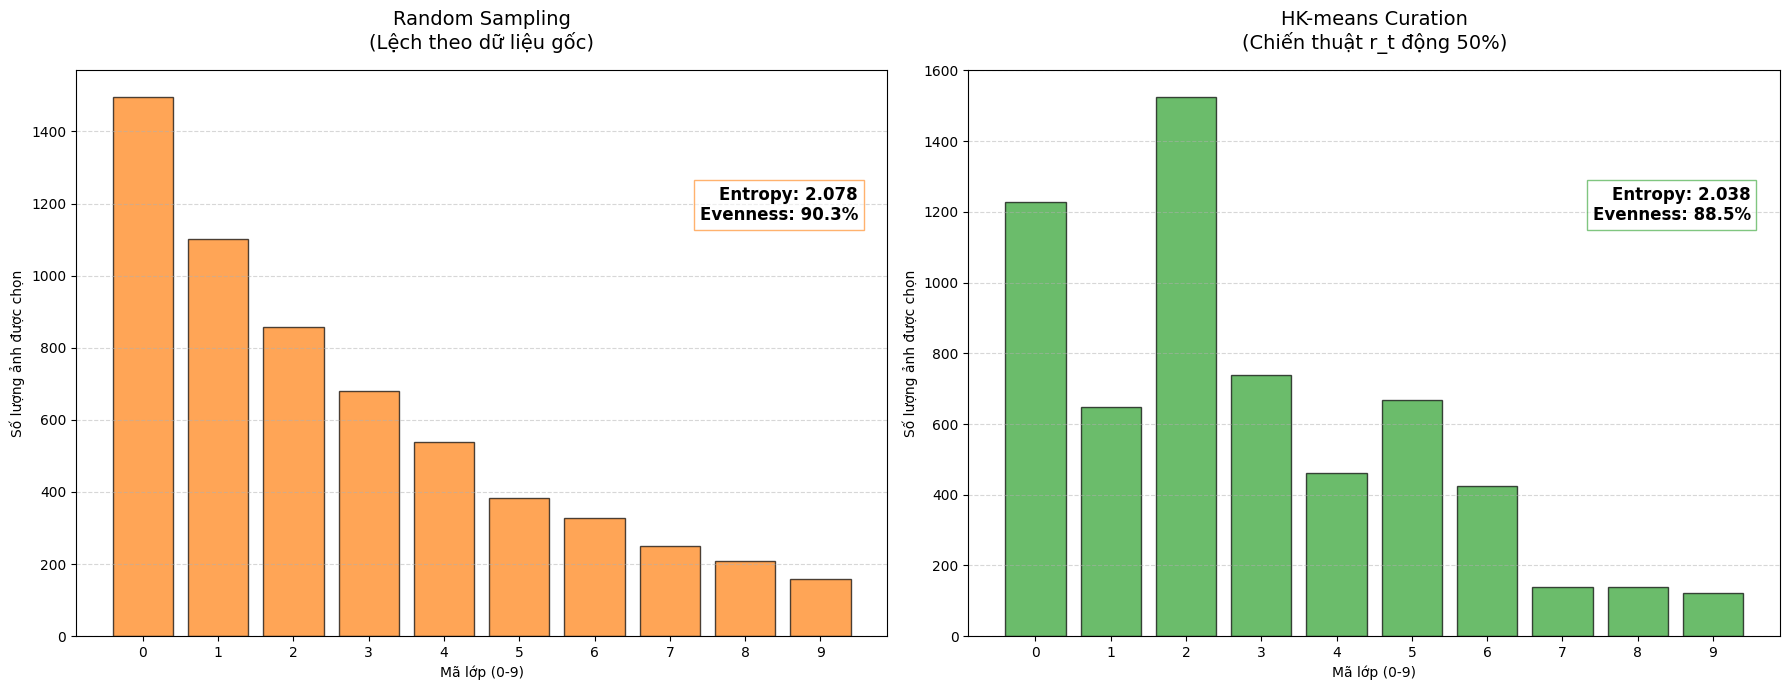

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def plot_distribution(y_data, title, color):
    # 1. Thống kê số lượng
    classes, counts = np.unique(y_data, return_counts=True)
    full_counts = np.zeros(10)
    for cls, count in zip(classes, counts):
        full_counts[int(cls)] = count
        
    # 2. TÍNH ENTROPY VÀ ĐỘ PHẲNG
    probs = full_counts / np.sum(full_counts)
    ent = entropy(probs)
    max_ent = np.log(10) # ln(10) xấp xỉ 2.302
    evenness = ent / max_ent
    
    # 3. VẼ BIỂU ĐỒ
    plt.bar(range(10), full_counts, color=color, alpha=0.7, edgecolor='black')
    
    # 4. CHÈN CHỈ SỐ LÊN HÌNH (Text box)
    info_text = f"Entropy: {ent:.3f}\nEvenness: {evenness:.1%}"
    # Đặt text ở vị trí phía trên bên phải của mỗi biểu đồ
    plt.text(9.5, max(full_counts) * 0.8, info_text, 
             fontsize=12, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor=color),
             ha='right', va='center')

    plt.xlabel('Mã lớp (0-9)')
    plt.ylabel('Số lượng ảnh được chọn')
    plt.title(title, fontsize=14, pad=15)
    plt.xticks(range(10))
    plt.grid(axis='y', linestyle='--', alpha=0.5)

# --- THỰC HIỆN VẼ ---
plt.figure(figsize=(18, 7))

# Biểu đồ bên trái: Random
plt.subplot(1, 2, 1)
# Giả sử Y_random_subset đã được tạo từ bước trước của bạn
plot_distribution(Y_random_subset, "Random Sampling\n(Lệch theo dữ liệu gốc)", "tab:orange")

# Biểu đồ bên phải: HK-means (Chiến thuật r_t động 50%)
plt.subplot(1, 2, 2)
# Dùng Y_curated_new bạn vừa tạo ra từ HK-means
plot_distribution(Y_curated_new, "HK-means Curation\n(Chiến thuật r_t động 50%)", "tab:green")

plt.tight_layout()
plt.show()


# --- CẤU HÌNH TỐI ƯU THỜI GIAN (10 PHÚT LEVEL 1) ---
T_steps = 3
# Level 1 để 1200 là đủ "mịn" cho 20k ảnh, 2000 là hơi dư thừa
k_list_fine = [1200, 800, 500] 

m_iterations = 10 # Giữ nguyên m=10 để centroids di chuyển tốt


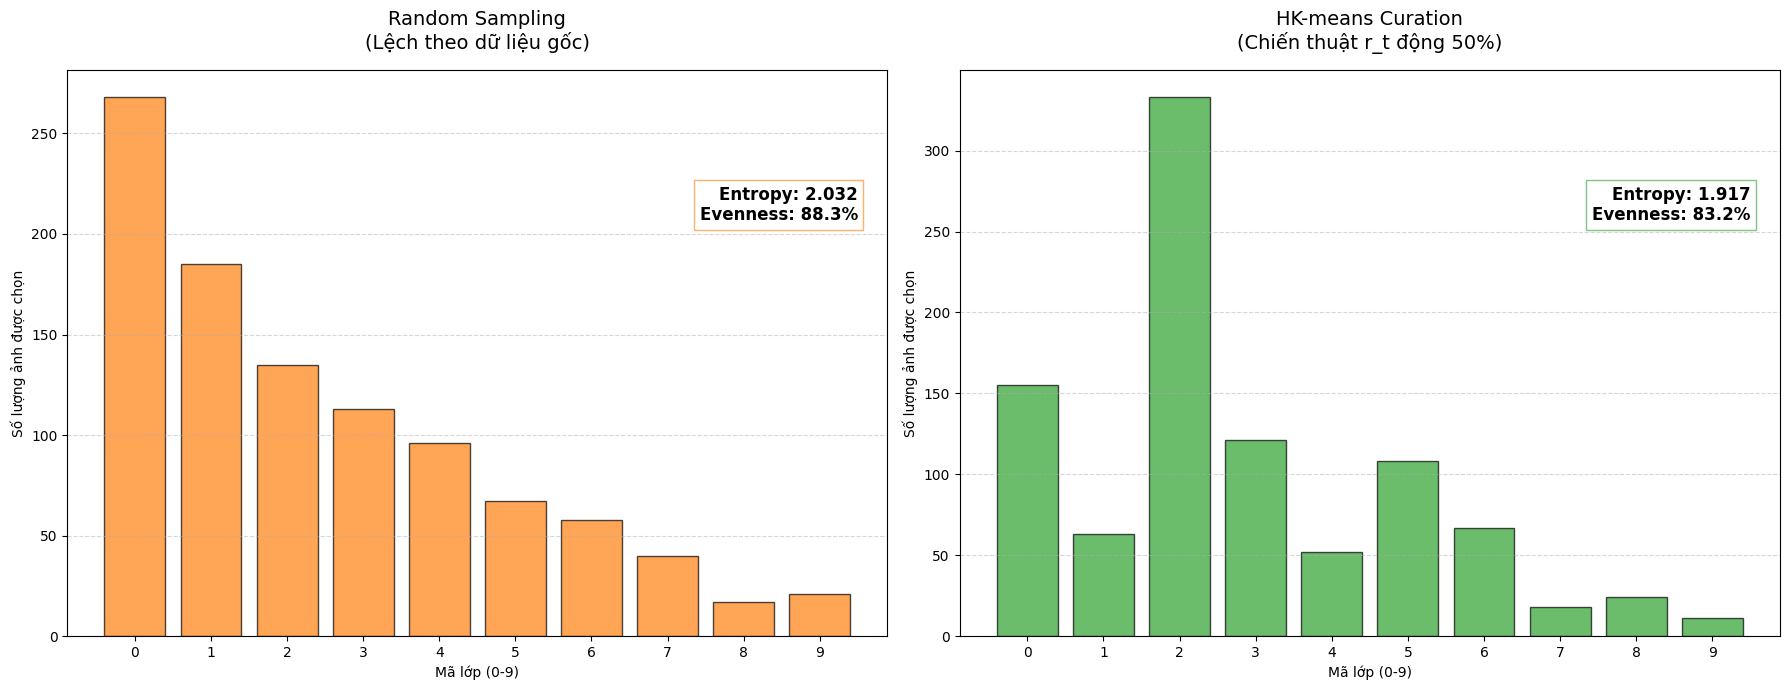

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def plot_distribution(y_data, title, color):
    # 1. Thống kê số lượng
    classes, counts = np.unique(y_data, return_counts=True)
    full_counts = np.zeros(10)
    for cls, count in zip(classes, counts):
        full_counts[int(cls)] = count
        
    # 2. TÍNH ENTROPY VÀ ĐỘ PHẲNG
    probs = full_counts / np.sum(full_counts)
    ent = entropy(probs)
    max_ent = np.log(10) # ln(10) xấp xỉ 2.302
    evenness = ent / max_ent
    
    # 3. VẼ BIỂU ĐỒ
    plt.bar(range(10), full_counts, color=color, alpha=0.7, edgecolor='black')
    
    # 4. CHÈN CHỈ SỐ LÊN HÌNH (Text box)
    info_text = f"Entropy: {ent:.3f}\nEvenness: {evenness:.1%}"
    # Đặt text ở vị trí phía trên bên phải của mỗi biểu đồ
    plt.text(9.5, max(full_counts) * 0.8, info_text, 
             fontsize=12, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor=color),
             ha='right', va='center')

    plt.xlabel('Mã lớp (0-9)')
    plt.ylabel('Số lượng ảnh được chọn')
    plt.title(title, fontsize=14, pad=15)
    plt.xticks(range(10))
    plt.grid(axis='y', linestyle='--', alpha=0.5)

# --- THỰC HIỆN VẼ ---
plt.figure(figsize=(18, 7))

# Biểu đồ bên trái: Random
plt.subplot(1, 2, 1)
# Giả sử Y_random_subset đã được tạo từ bước trước của bạn
plot_distribution(Y_random_subset, "Random Sampling\n(Lệch theo dữ liệu gốc)", "tab:orange")

# Biểu đồ bên phải: HK-means (Chiến thuật r_t động 50%)
plt.subplot(1, 2, 2)
# Dùng Y_curated_new bạn vừa tạo ra từ HK-means
plot_distribution(Y_curated_new, "HK-means Curation\n(Chiến thuật r_t động 50%)", "tab:green")

plt.tight_layout()
plt.show()

X_feat_norm = normalize(X_features, axis=1)

T_steps = 3
k_list_fine = [2000, 1000, 800]
m_iterations = 15 # Tăng m để tăng độ phẳng

# Gọi hàm với r_t tự động tính bên trong như bạn muốn
centroids_cifar = hierarchical_kmeans_resampling(
    X_feat_norm, 
    k_list_fine, 
    T=T_steps, 
    m=m_iterations, 
  
    num_init=5
)


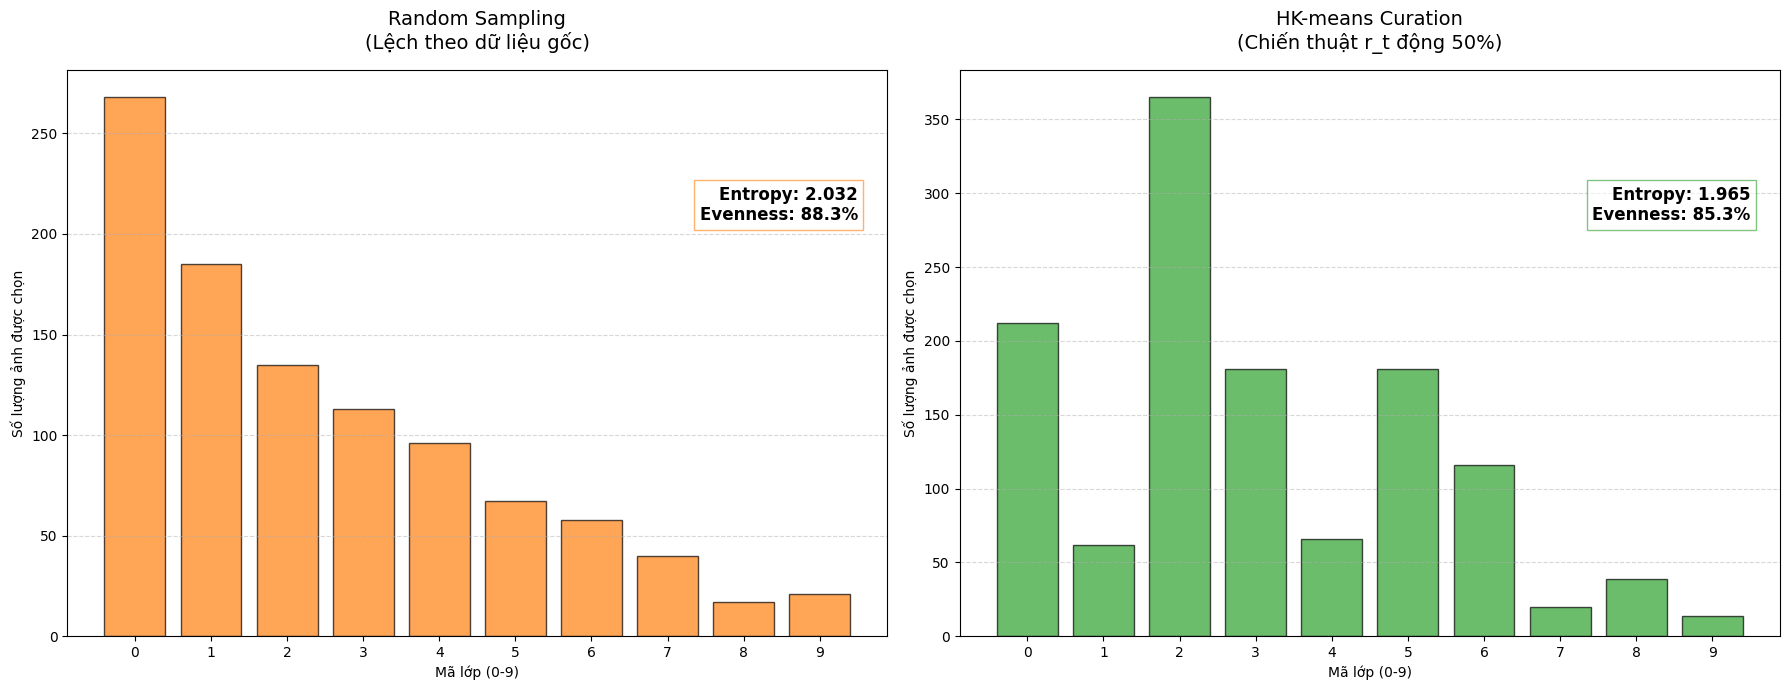

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def plot_distribution(y_data, title, color):
    # 1. Thống kê số lượng
    classes, counts = np.unique(y_data, return_counts=True)
    full_counts = np.zeros(10)
    for cls, count in zip(classes, counts):
        full_counts[int(cls)] = count
        
    # 2. TÍNH ENTROPY VÀ ĐỘ PHẲNG
    probs = full_counts / np.sum(full_counts)
    ent = entropy(probs)
    max_ent = np.log(10) # ln(10) xấp xỉ 2.302
    evenness = ent / max_ent
    
    # 3. VẼ BIỂU ĐỒ
    plt.bar(range(10), full_counts, color=color, alpha=0.7, edgecolor='black')
    
    # 4. CHÈN CHỈ SỐ LÊN HÌNH (Text box)
    info_text = f"Entropy: {ent:.3f}\nEvenness: {evenness:.1%}"
    # Đặt text ở vị trí phía trên bên phải của mỗi biểu đồ
    plt.text(9.5, max(full_counts) * 0.8, info_text, 
             fontsize=12, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor=color),
             ha='right', va='center')

    plt.xlabel('Mã lớp (0-9)')
    plt.ylabel('Số lượng ảnh được chọn')
    plt.title(title, fontsize=14, pad=15)
    plt.xticks(range(10))
    plt.grid(axis='y', linestyle='--', alpha=0.5)

# --- THỰC HIỆN VẼ ---
plt.figure(figsize=(18, 7))

# Biểu đồ bên trái: Random
plt.subplot(1, 2, 1)
# Giả sử Y_random_subset đã được tạo từ bước trước của bạn
plot_distribution(Y_random_subset, "Random Sampling\n(Lệch theo dữ liệu gốc)", "tab:orange")

# Biểu đồ bên phải: HK-means (Chiến thuật r_t động 50%)
plt.subplot(1, 2, 2)
# Dùng Y_curated_new bạn vừa tạo ra từ HK-means
plot_distribution(Y_curated_new, "HK-means Curation\n(Chiến thuật r_t động 50%)", "tab:green")

plt.tight_layout()
plt.show()

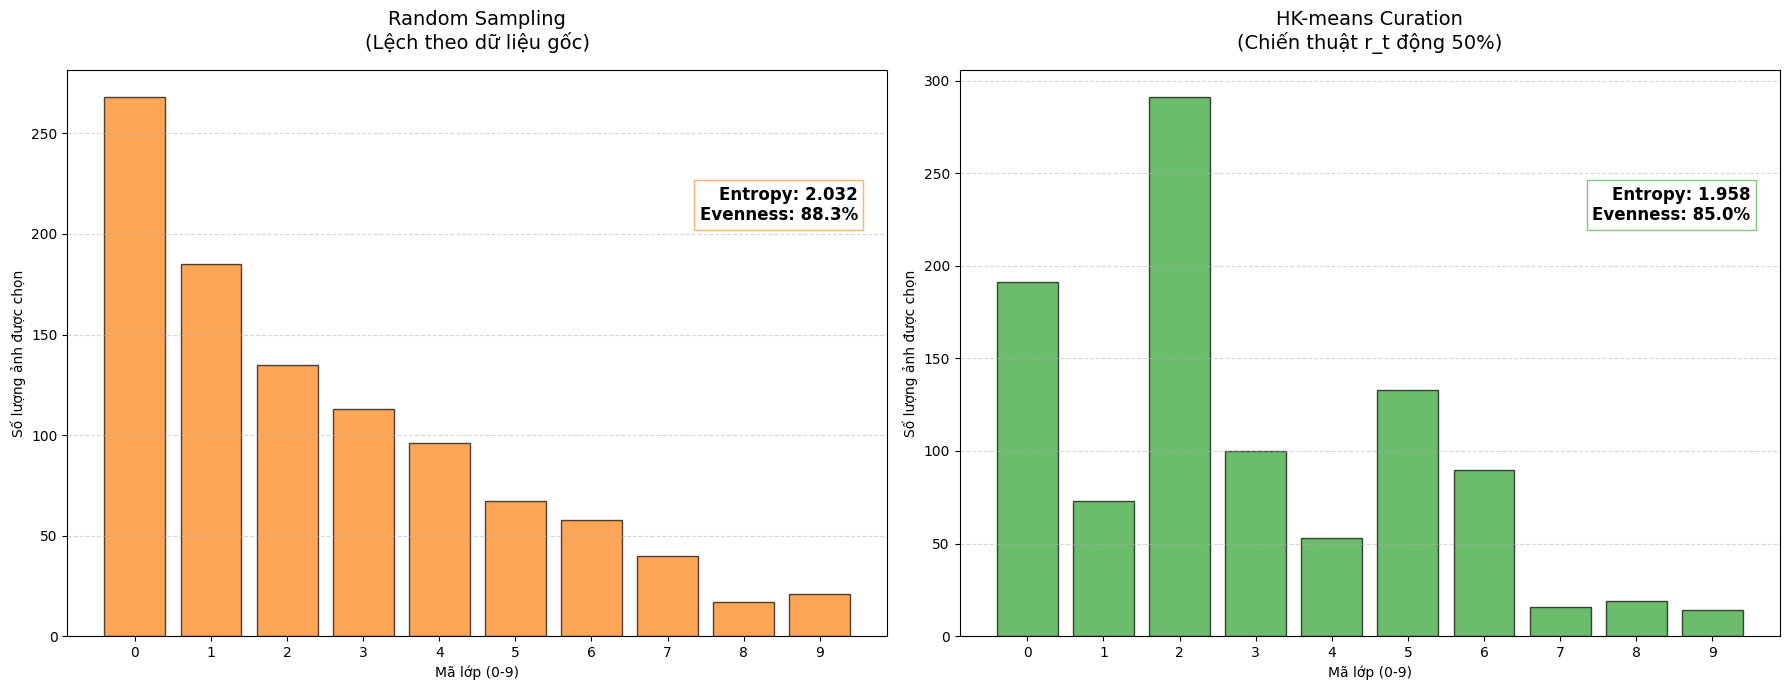

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def plot_distribution(y_data, title, color):
    # 1. Thống kê số lượng
    classes, counts = np.unique(y_data, return_counts=True)
    full_counts = np.zeros(10)
    for cls, count in zip(classes, counts):
        full_counts[int(cls)] = count
        
    # 2. TÍNH ENTROPY VÀ ĐỘ PHẲNG
    probs = full_counts / np.sum(full_counts)
    ent = entropy(probs)
    max_ent = np.log(10) # ln(10) xấp xỉ 2.302
    evenness = ent / max_ent
    
    # 3. VẼ BIỂU ĐỒ
    plt.bar(range(10), full_counts, color=color, alpha=0.7, edgecolor='black')
    
    # 4. CHÈN CHỈ SỐ LÊN HÌNH (Text box)
    info_text = f"Entropy: {ent:.3f}\nEvenness: {evenness:.1%}"
    # Đặt text ở vị trí phía trên bên phải của mỗi biểu đồ
    plt.text(9.5, max(full_counts) * 0.8, info_text, 
             fontsize=12, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor=color),
             ha='right', va='center')

    plt.xlabel('Mã lớp (0-9)')
    plt.ylabel('Số lượng ảnh được chọn')
    plt.title(title, fontsize=14, pad=15)
    plt.xticks(range(10))
    plt.grid(axis='y', linestyle='--', alpha=0.5)

# --- THỰC HIỆN VẼ ---
plt.figure(figsize=(18, 7))

# Biểu đồ bên trái: Random
plt.subplot(1, 2, 1)
# Giả sử Y_random_subset đã được tạo từ bước trước của bạn
plot_distribution(Y_random_subset, "Random Sampling\n(Lệch theo dữ liệu gốc)", "tab:orange")

# Biểu đồ bên phải: HK-means (Chiến thuật r_t động 50%)
plt.subplot(1, 2, 2)
# Dùng Y_curated_new bạn vừa tạo ra từ HK-means
plot_distribution(Y_curated_new, "HK-means Curation\n(Chiến thuật r_t động 50%)", "tab:green")

plt.tight_layout()
plt.show()

# --- CẤU HÌNH TỐI ƯU ---
X_feat_norm = normalize(X_features, axis=1)

T_steps = 3
k_list_fine = [1000, 750, 500] 
m_iterations = 10 # Tăng m để tăng độ phẳng

# Gọi hàm với r_t tự động tính bên trong như bạn muốn
centroids_cifar = hierarchical_kmeans_resampling(
    X_feat_norm, 
    k_list_fine, 
    T=T_steps, 
    m=m_iterations, 
  
    num_init=5
)
